In [1]:
%matplotlib inline

In [2]:
import xtrack as xt
import xpart as xp
import xobjects as xo
import matplotlib.pyplot as plt

import numpy as np

In [3]:
p0_carbon = xt.Particles('Carbon-12', q0=6)
p0_helium = xt.Particles('Helium-4', q0=2)

In [4]:
p0_carbon.pdg_id, p0_helium.pdg_id

(array([1000060120]), array([1000020040]))

In [5]:
mass_ratio_he_ca = p0_helium.mass0 / p0_carbon.mass0
charge_ratio_he_ca = p0_helium.q0 / p0_carbon.q0

In [6]:
env = xt.load('./pimm.json')
env.vars.load('./pimm_strengths.json')

line = env.ring
# line.configure_bend_model(core='bend-kick-bend')#num_multipole_kicks=5)
line.configure_bend_model(num_multipole_kicks=5)
line.set_particle_ref('Carbon-12', q0=6, kinetic_energy0=200e6 * 12)

tw4d = line.twiss4d()
eta = tw4d.slip_factor
line_length = tw4d.line_length

line['vrf'] = 0 # Debunched beam
line['frf'] = 1 / tw4d.t_rev0 # h=1

Loading line from dict:   0%|          | 0/86 [00:00<?, ?it/s]

In [7]:
opt = line.match(
    solve=False, # <- prepare the match without running it
    chrom=False,
    method='4d',
    vary=[
        xt.Vary('kqfa', limits=(0, 10),  step=1e-3),
        xt.Vary('kqfb', limits=(0, 10),  step=1e-3),
        xt.Vary('kqd', limits=(-10, 0), step=1e-3),
    ],
    targets=[
        xt.TargetSet(qx=1.665, qy=1.72, tol=1e-4),
        xt.TargetSet(dx=0, at='mid.lss.0', tol=2e-3),
        xt.TargetSet(dx=0, at='mid.lss.1', tol=2e-3),
    ]
)
opt.step(20)
opt.target_status()

                                             
Optimize - start penalty: 0.2504                            
Matching: model call n. 13 penalty = 1.5671e-05              
Optimize - end penalty:  1.56713e-05                            
Target status:               nalty = 1.5671e-05              
id state tag          tol_met       residue   current_val    target_val description                                 
0  ON    qx              True    3.4103e-07         1.665         1.665 'qx', val=1.665, tol=0.0001, weight=10      
1  ON    qy              True   2.50955e-08          1.72          1.72 'qy', val=1.72, tol=0.0001, weight=10       
2  ON    mid.lss.0_dx    True  -1.07975e-06  -1.07975e-06             0 ('dx', 'mid.lss.0'), val=0, tol=0.002, w ...
3  ON    mid.lss.1_dx    True   -1.0831e-06   -1.0831e-06             0 ('dx', 'mid.lss.1'), val=0, tol=0.002, w ...


In [8]:
env.new('extr_septum', xt.Marker)
env.new('septum_aperture', xt.LimitRect, min_x=-0.1, max_x=0.1, min_y=-0.1, max_y=0.1),

line.insert(['extr_septum', 'septum_aperture'], at=0)



Slicing line:   0%|          | 0/109 [00:00<?, ?it/s]

In [9]:
env['kse'] = 3.

In [10]:
x_gen = np.linspace(0, 1e-2, 20)
p = line.build_particles(x=x_gen, px=0, y=0, py=0, zeta=0, delta=0)

In [11]:
line.track(p, num_turns=1000, turn_by_turn_monitor=True,
           with_progress=True)

Tracking:   0%|          | 0/1000 [00:00<?, ?it/s]

In [12]:
rec = line.record_last_track

In [13]:
x_septum = 3.5e-2

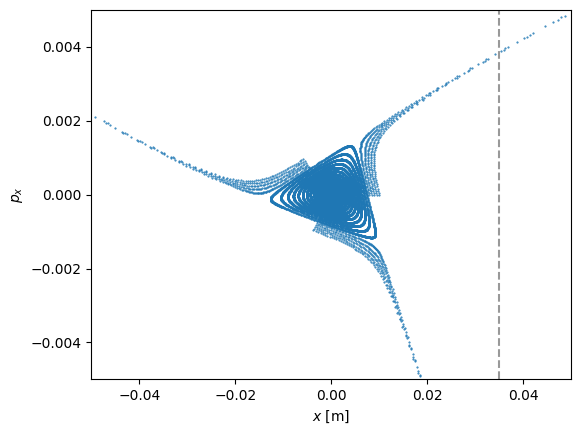

In [14]:
# Plot turn-by-turn data
plt.figure()
plt.plot(rec.x.T, rec.px.T, '.', markersize=1, color='C0')
plt.xlabel(r'$x$ [m]'); plt.ylabel(r'$p_x$'), plt.xlim(-5e-2, 5e-2); plt.ylim(-5e-3, 5e-3)
plt.axvline(x=x_septum, color='k', alpha=0.4, linestyle='--')
plt.subplots_adjust(left=.15)

### Build a matched beam distribution

In [15]:
num_particles = 3000
beam_intensity = 1e10 # p+

# Generate Gaussian distribution in normalized phase space
x_norm = np.random.normal(size=num_particles)
px_norm = np.random.normal(size=num_particles)
y_norm = np.random.normal(size=num_particles)
py_norm = np.random.normal(size=num_particles)

# Generate Gaussian momentum distribution (rms spread 5e-4)
delta = 5e-4 * np.random.normal(size=num_particles)

# Particles arrival time spread over one turn
zeta = np.random.uniform(size=num_particles) * line.get_length()

# Assemble Particles object
particles = line.build_particles(
    x_norm=x_norm, px_norm=px_norm, 
    y_norm=y_norm, py_norm=py_norm,
    delta=delta,
    zeta=zeta,
    method='4d',
    weight=beam_intensity / num_particles,
    nemitt_x=1.5e-6, nemitt_y=1e-6,
)

# save initial state
p0 = particles.copy()

### Define time-dependent behavior of extraction sextupoles

In [16]:
line.functions['fun_xsext'] = xt.FunctionPieceWiseLinear(x=[0, 0.1e-3, 0.5e-3], y=[0, 0, 1.])

line.ref['kse'] *= line.functions['fun_xsext'](line.vars['t_turn_s'])

# Inspect the expression
line.ref['kse']._expr

(3.0 * f['fun_xsext'](vars['t_turn_s']))

In [17]:
line['septum_aperture'].max_x = x_septum

In [18]:
ctx = xo.ContextCpu(omp_num_threads='auto')
line.build_tracker(_context=ctx)

Compiling ContextCpu kernels...


ld: warning: duplicate -rpath '/Users/giadarol/miniforge3/envs/py313/lib' ignored
ld: warning: duplicate -rpath '/Users/giadarol/miniforge3/envs/py313/lib' ignored


Done compiling ContextCpu kernels.


In [19]:
# User-defined quantity to be logged
def measure_intensity(line, particles):
    mask_alive = particles.state > 0
    intensity = np.sum(particles.weight[mask_alive])
    return intensity

log = xt.Log('kse',              # vars to be logged
             intensity=measure_intensity) # user-defined function to be logged

In [20]:
line.enable_time_dependent_vars = True

In [21]:
line.track(particles, num_turns=5000, with_progress=True,
           log=log)

Tracking:   0%|          | 0/5000 [00:00<?, ?it/s]

Text(0, 0.5, 'Intensity [$p^+$]')

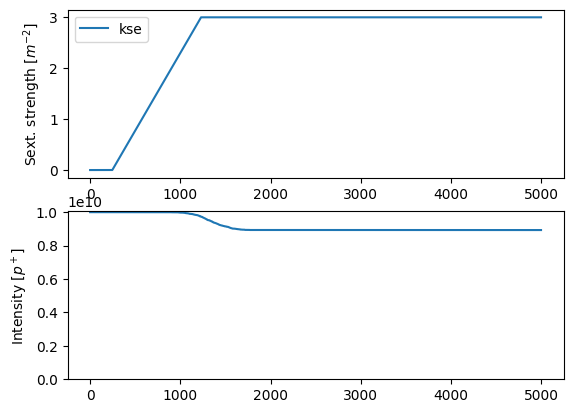

In [23]:
plt.figure()

ax1 = plt.subplot(2,1,1)
plt.plot(line.log_last_track['kse'], label='kse')
plt.ylabel('Sext. strength [$m^{-2}$]')
plt.legend()

ax2 = plt.subplot(2,1,2, sharex=ax1)
plt.plot(line.log_last_track['intensity'])
plt.ylim(bottom=0)
plt.ylabel('Intensity [$p^+$]')

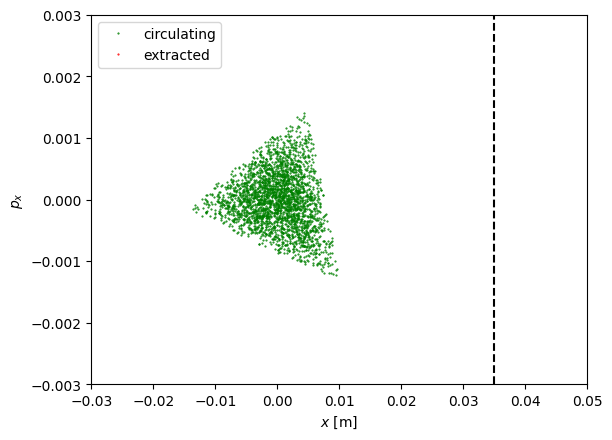

In [24]:
plt.figure()
mask_alive = particles.state>0
mask_lost = ~mask_alive
plt.plot(particles.x[mask_alive], particles.px[mask_alive],
         '.', markersize=1, color='green', label='circulating')
plt.plot(particles.x[mask_lost], particles.px[mask_lost],
         '.', markersize=1, color='red', label='extracted')
plt.xlabel('$x$ [m]'); plt.ylabel('$p_x$')
plt.axvline(x=line['septum_aperture'].max_x, color='k', ls='--')
plt.xlim(-0.03, 0.05); plt.ylim(-3e-3, 3e-3)
plt.legend()
plt.show()